# Notebook Python - Projet Machine Learning 

*Lucas Rosas, Jeanne Marque, Clélia Desjean, Laura Souverin*

---

In [2]:
#import des bibliothèques utilisées dans le projet

import numpy as np
import pandas as pd
import matplotlib as mlt
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import jinja2 as j2
import math
import statsmodels.api as sm

## 1-Import et modification des données 

### 1.1- Import des données et vérifications du contenu

In [3]:
#Importer les données 
path=""
health=pd.read_csv(path+"healthcare_synthetic_data.csv", sep=",", header=0)

#On vérifie le contenu
health.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [4]:
data_quality = pd.DataFrame({
    "colonne": health.columns,
    "n_unique": health.nunique().values,
    "n_missing": health.isna().sum().values,
    "missing_ratio": (health.isna().sum() / len(health)).values,
    "dtype": health.dtypes.astype(str).values
})
    # création visuel coloré
affichage_colore = (
    data_quality.style
    .background_gradient(subset=['n_missing', 'missing_ratio'], cmap='Reds')
    .bar(subset=['n_unique'], color='#5fba7d')
    .format({'missing_ratio': '{:.2%}'})
    .map(lambda x: 'font-weight: bold', subset=['colonne'])
)
display(affichage_colore)

,colonne,n_unique,n_missing,missing_ratio,dtype
0,Patient_ID,15000,0,0.00%,str
1,Age,61,0,0.00%,int64
2,Gender,2,0,0.00%,int64
3,Height_cm,516,0,0.00%,float64
4,Weight_kg,817,0,0.00%,float64
5,BMI,274,0,0.00%,float64
6,Systolic_BP,82,0,0.00%,int64
7,Diastolic_BP,61,0,0.00%,int64
8,Cholesterol_Total,161,0,0.00%,int64
9,Cholesterol_LDL,132,0,0.00%,int64


### 1.2- Modification des données 

Afin d'utiliser les méthodes de machine learning, certaines modifications doivent être apportées aux données.

**a) Modification des types**

Nous transformons les variables qualitatives en type *Categorical* pour préparer l'encodage binaire. Cela permet au modèle de traiter chaque catégorie séparément, sans établir d'ordre mathématique entre elles.


**NOTE : faut il transformer stress_level... ?**


In [5]:
health['Patient_ID'] = pd.Categorical(health['Patient_ID'])
health['Gender'] = pd.Categorical(health['Gender'])
health['Smoking_Status'] = pd.Categorical(health['Smoking_Status'])
health['Alcohol_Consumption'] = pd.Categorical(health['Alcohol_Consumption'])
health['Physical_Activity_Level'] = pd.Categorical(health['Physical_Activity_Level'])
health['Family_History'] = pd.Categorical(health['Family_History'])
health['Stress_Level'] = pd.Categorical(health['Stress_Level'])
health['Sleep_Hours'] = pd.Categorical(health['Sleep_Hours'])
health['Heart_Disease_Risk'] = pd.Categorical(health['Heart_Disease_Risk'])

health.describe()

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000



**b) Transformation en Gaussienne**

On définit une fonction pour observer la distribution de nos variables quantitatives 

In [6]:
def plot_quantitative(df):
    # Sélectionner les colonnes numériques du DataFrame
    vars_num = df.select_dtypes(include=['number']).columns
    n_vars = len(vars_num)
    
    # si toutes nos variables sont qualitatives, on affiche un message et on quitte la fonction
    if n_vars == 0:
        print("Aucune variable numérique trouvée.")
        return

    # Calculer le nombre de lignes nécessaires pour 3 colonnes dans la grille 
    ncols = 3
    nrows = math.ceil(n_vars / ncols)

    # Créer la figure et les axes
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()  # Aplatir pour itérer facilement

    for i, col in enumerate(vars_num):
        # Création de l'histogramme + densité (kde)
        sns.histplot(df[col], kde=True, stat="density", 
                     color="grey", edgecolor="black",bins=30, 
                     line_kws={"color": "blue"}, ax=axes[i])
        
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Density")
        axes[i].grid(True, alpha=0.3)

    # Supprimer les graphiques vides si n_vars n'est pas un multiple de 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

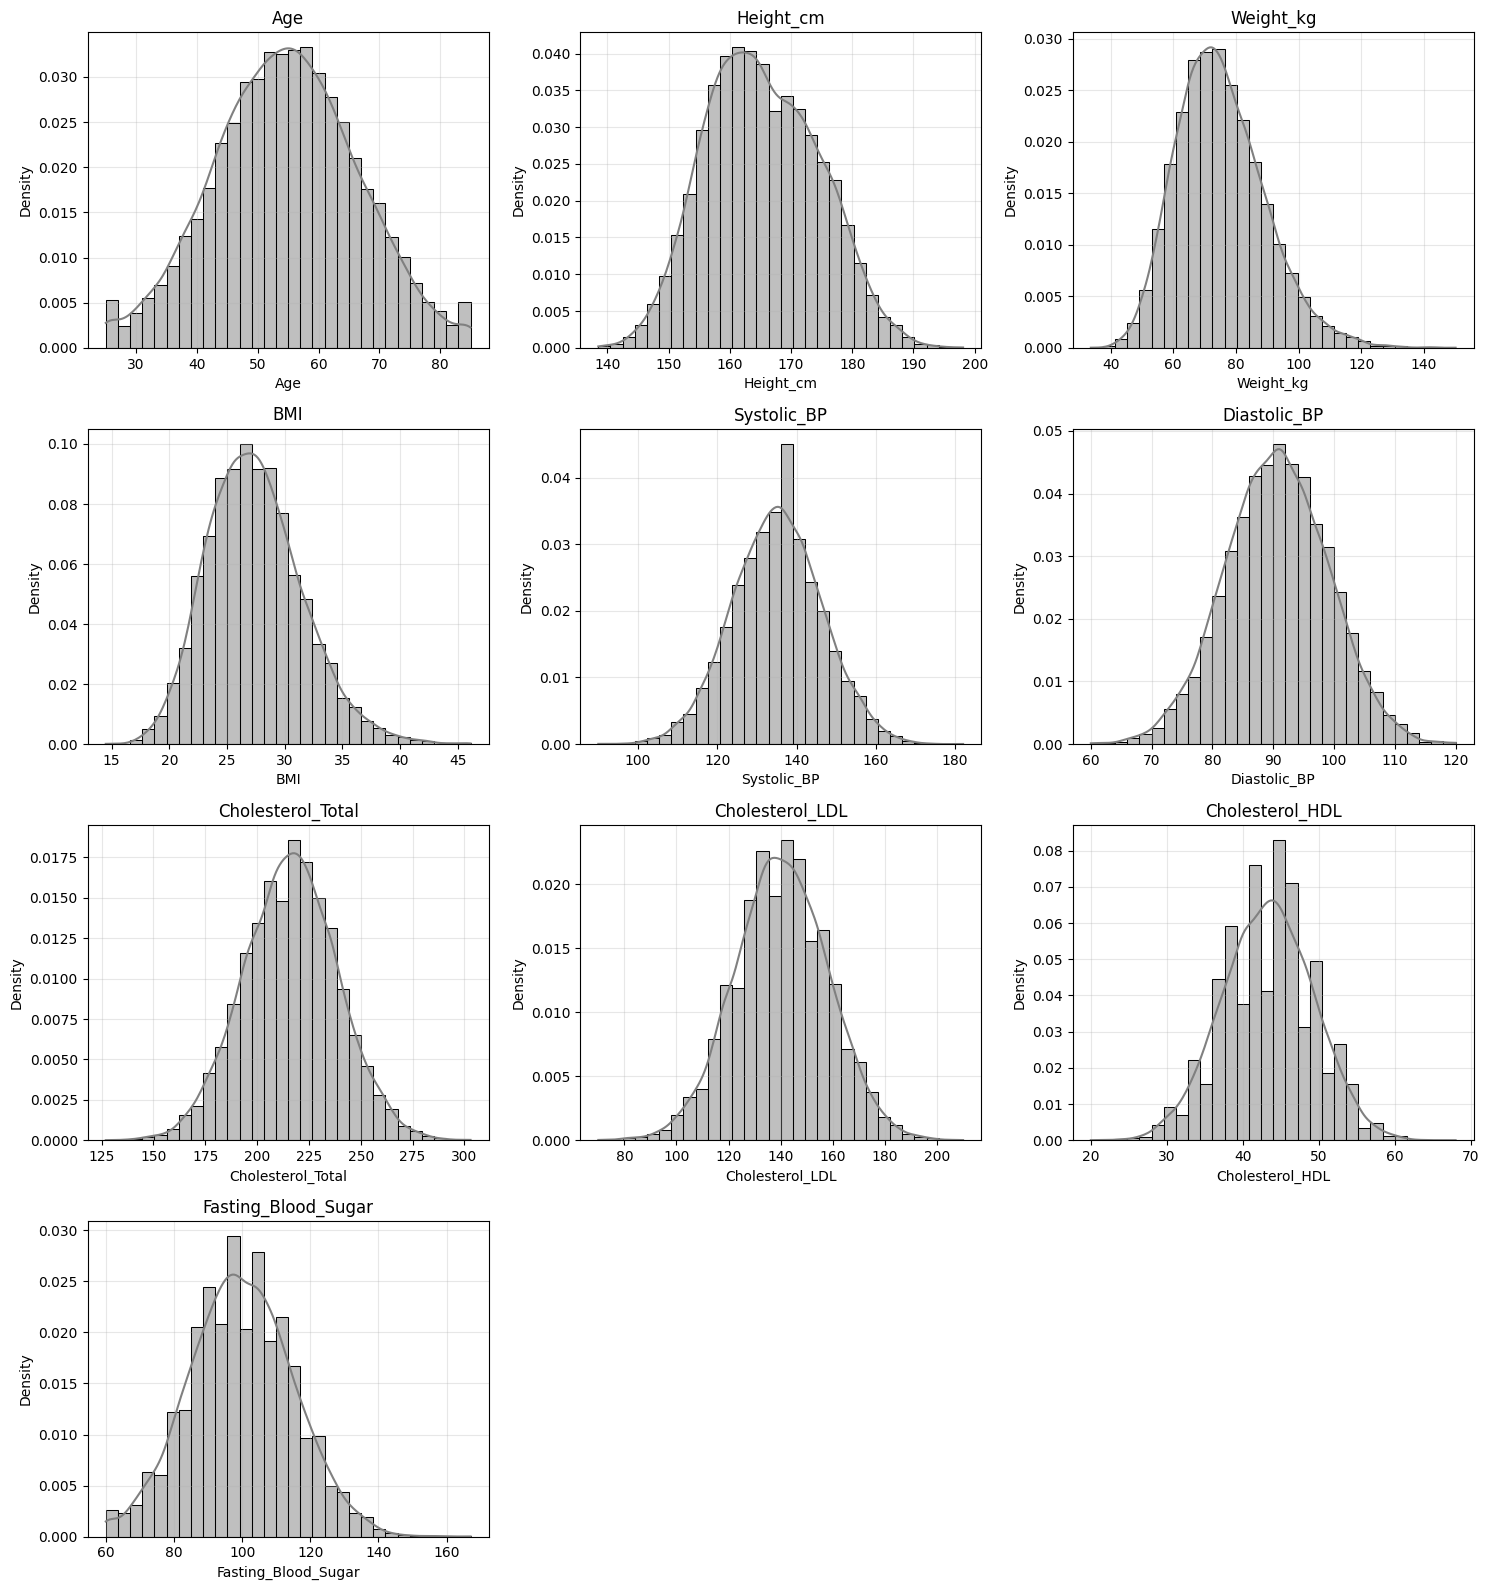

In [7]:
#on l'utilise sur notre dataset original 
plot_quantitative(health)

Nous pouvons observer que certaines variables, telles que l'âge ou le taux de cholestérol, sont relativement gaussiennes. Certaines sont asymétriques ou présentent de nombreux "trous". On transforme celles-ci en variables gaussiennes. Ceci est nécessaire à certaines méthodes et permet aussi d'améliorer les performances et la stabilité de certains modèles, car la structure gaussienne est prévisible et régulière.

On utilise deux types de transformations : 
* *transformation logarithmique*: On applique cette transformation aux donnnées  (avec une trainée vers la droite)
* *transformation quantile*: On l'applique aux données avec des "pics" 

**NOTE / est ce que ça nous fait perdre des infos ?**

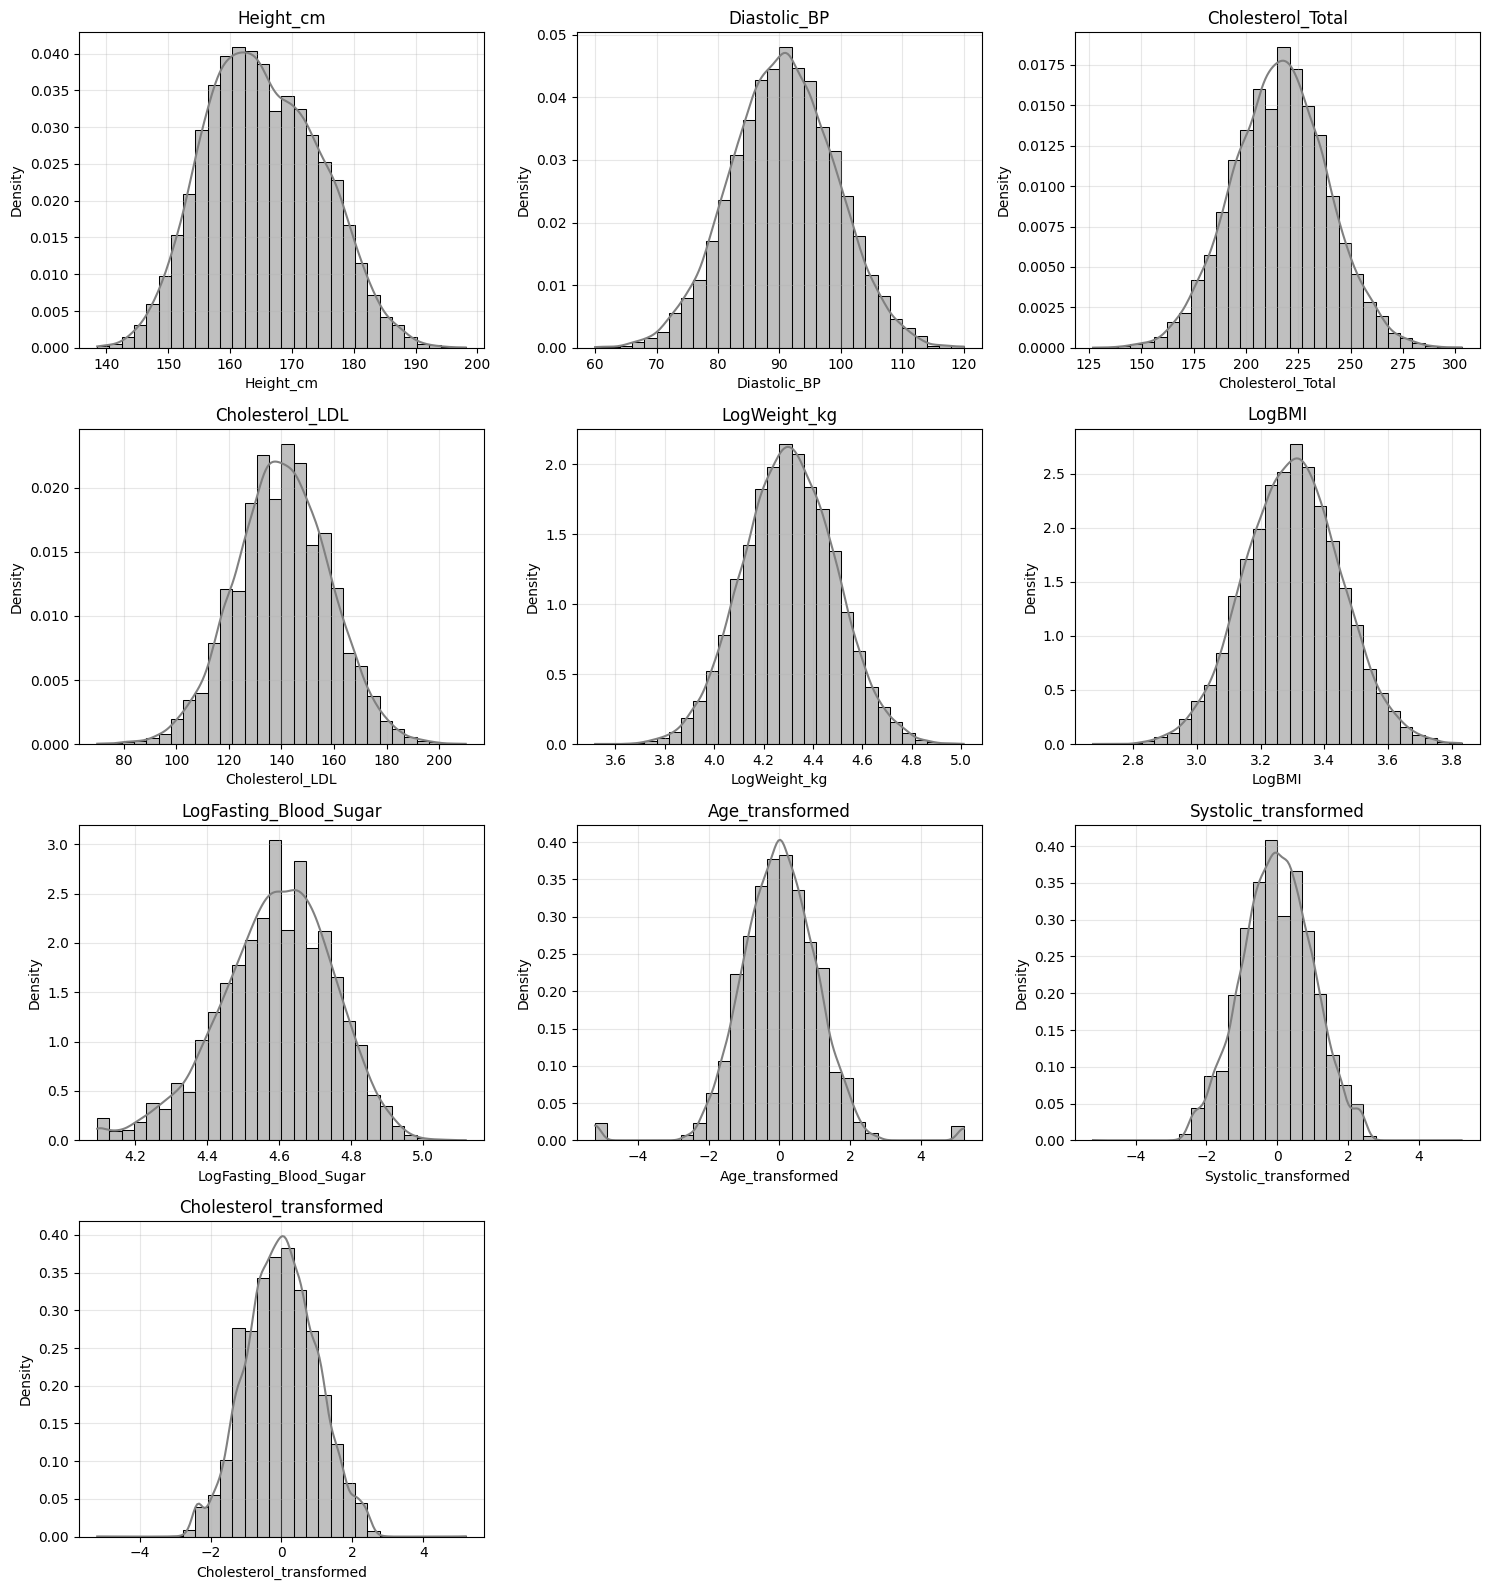

In [8]:
# on applique une transformation LOG sur les variables très asymétriques 
log_transformations = {
    "Weight_kg": "LogWeight_kg",
    "BMI": "LogBMI",
    "Fasting_Blood_Sugar": "LogFasting_Blood_Sugar"
}

#on applique une transformation QUANTILE sur les variables avec des outliers
# cette transformation trie les données et associe à chaque valeur un quantile de la distribution normale
qt_transformations = {
    "Age": "Age_transformed",
    "Systolic_BP": "Systolic_transformed",
    "Cholesterol_HDL": "Cholesterol_transformed"
}

# cette boucle nous permet de pouvoir relancer la cellule plusieurs fois sans erreur. Si la source n'existe plus, on ne fait rien
for old_col, new_col in log_transformations.items():
    if old_col in health.columns:
        health[new_col] = np.log(health[old_col])
        health = health.drop(columns=[old_col]) # On supprime l'originale tout de suite


from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(output_distribution='normal', n_quantiles=100)
#pareil pour la transformation quantile
for old_col, new_col in qt_transformations.items():
    if old_col in health.columns:
        health[new_col] = qt.fit_transform(health[[old_col]])
        health = health.drop(columns=[old_col])

#Affichage
plot_quantitative(health)

Il y a encore des défauts, on observe des "pics" ou des "trous" et des valeurs aberrantes. Cependant, ceci est lié à l'arrondi des données de santé, l'affichage... Les données sont assez gaussiennes pour notre utilisation. **NOTE: ON EST SUr?**

**c) Transformation des données pour l'apprentissage**

On commence par séparer les variables explicatives de la variable à expliquer. De plus, on utilise la fonction `pd.get_dummies` afin d'effectuer le *one hot encoding* de nos variables qualitatives. Elles se transforment ainsi en variables binaires indiquant si elles appartiennent, ou non, à chaque catégorie. 

In [9]:
#on définit la cible : le Heart_Disease_Risk, celle ci est binaire et indique si le patient est à risque de maladie cardiaque ou non
health_target = health['Heart_Disease_Risk']

health_features = health.drop(['Heart_Disease_Risk', 'Patient_ID'], axis=1)# Patient_ID est une variable catégorielle qui n'apporte pas d'information pour la prédiction

health_features = pd.get_dummies(health_features, columns=['Gender', 'Smoking_Status', 'Family_History', 'Alcohol_Consumption'], drop_first=True)

**NOTE: tjr meme question est ce que les stress level etc doivent être en dummies**

Afin de sélectionner le meilleur modèle et de detecter l'over-fitting, nous devons créer un dataset de test. Nous séparons donc nos données en deux dataset.

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(health_features, health_target, test_size=0.2, train_size=0.8) # on renomme en X/y pour la lisibilité
print("la dimension de X_train est : ", np.shape(X_train))
print("la dimension de X_test est : ", np.shape(X_test))
print("la dimension de Y_train est : ", np.shape(Y_train))
print("la dimension de Y_test est : ", np.shape(Y_test))


la dimension de X_train est :  (12000, 18)
la dimension de X_test est :  (3000, 18)
la dimension de Y_train est :  (12000,)
la dimension de Y_test est :  (3000,)


On normalise les variables. Cela permet de comparer des valeurs avec differentes échelles et éviter qu'un attribut ait une influence démesurée sur le modèle. 

In [11]:
from sklearn.preprocessing import StandardScaler  

scaler = StandardScaler()  
scaler.fit(X_train)  
Xs_train= scaler.transform(X_train)  
# Meme transformation sur le test -> on part du principe que les données de test suivent la même distribution que les données d'entraînement, on applique donc la même transformation
Xs_test= scaler.transform(X_test)

## 2-Modèles linéaires 

Dans cette partie, nous utilisons les modèles linéaires, dont l'objectif est de prédire notre variable à expliquer grâce à une relation linéaire entre les variables explicatives. Puisque notre variable à expliquer est binaire, nous avons recours à la *régression logistique*. Plutôt que de prédire directement une valeur brute, cette méthode estime la probabilité que chaque observation appartienne à la classe positive, permettant ainsi de modéliser le risque de problèmes cardiaques.

### 2.1-Modèle linéaire sans pénalisation, sans sélection de variable 

**a) Avec librarie sklearn**

Nous commençons notre analyse par une régression logistique sans pénalisation ni sélection de variable. Nous utilisons la librairie `sklearn`

In [12]:
from sklearn.linear_model import LogisticRegression

logReg_none = LogisticRegression(penalty=None, max_iter=10000) # on initialise le modèle, le max_iter est mis à 10000 pour être sûr que le modèle converge, on veut faire sans pénalité pour commencer.  
logReg_none.fit(Xs_train, Y_train)

c:\Users\souve\Bureau\projet-MLBBL\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

Pour juger les performances de notre modèle, nous utilisons notre dataset de test. 

In [13]:
from sklearn.metrics import accuracy_score, classification_report

# Prédiction
Y_pred_lrn = logReg_none.predict(Xs_test)

# Affichage du score (Précision globale)
print(f"Précision du modèle : {accuracy_score(Y_test, Y_pred_lrn):.3%}")

# Détail des performances (Précision, Rappel par classe)
print(classification_report(Y_test, Y_pred_lrn))

Précision du modèle : 72.733%
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      1691
           1       0.72      0.62      0.66      1309

    accuracy                           0.73      3000
   macro avg       0.73      0.72      0.72      3000
weighted avg       0.73      0.73      0.72      3000



Pour un affichage plus clair, on construit la matrice de confusion. 

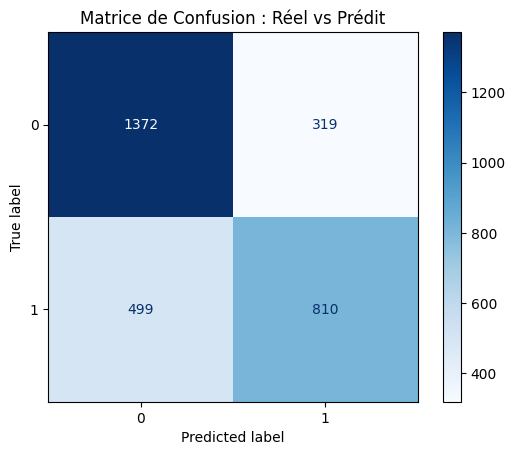

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Générer la matrice
cm = confusion_matrix(Y_test, Y_pred_lrn)

# L'afficher de manière élégante
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logReg_none.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion : Réel vs Prédit")
plt.show()

**b)Avec la librairie statsmodels**

La librairie `sklearn` nous permet d'observer les résultats mais ne nous donne pas le détail du modèle. La librairie `statsmodels`, au contraire, nous permet de voir les poids de chaque variable, et donc de les analyser. 

In [15]:
#elle utilise une df avec les noms et un intercept
# Pour retrouver les noms dans le summary de statsmodels
X_train_df = pd.DataFrame(Xs_train, columns=health_features.columns)
X_train_df = sm.add_constant(X_train_df) # on ajoute un intercept pour que le modèle puisse apprendre une constante ( pas automatique dans la libraire)

# on fait la même chose pour le dataset de test 

X_test_df = pd.DataFrame(Xs_test, columns=health_features.columns)
X_test_df = sm.add_constant(X_test_df)

regLog_stat = sm.Logit(Y_train.reset_index(drop=True), X_train_df).fit()
print(regLog_stat.summary())


Optimization terminated successfully.
         Current function value: 0.524448
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:     Heart_Disease_Risk   No. Observations:                12000
Model:                          Logit   Df Residuals:                    11981
Method:                           MLE   Df Model:                           18
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.2343
Time:                        09:52:47   Log-Likelihood:                -6293.4
converged:                       True   LL-Null:                       -8218.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.3196      0.022    -14.540      0.000      -0.363   

In [16]:
Y_prob_stat =regLog_stat.predict(X_test_df) # car statsmodels nous donne la probabilité
Y_pred_stat = (Y_prob_stat >= 0.5).astype(int) # On doit Convertir en binaire (0 si proba < 0.5, sinon 1)

# Affichage du score (Précision globale)
print(f"Précision du modèle : {accuracy_score(Y_test, Y_pred_stat):.3%}")

# Détail des performances (Précision, Rappel par classe)
print(classification_report(Y_test, Y_pred_stat))

Précision du modèle : 72.700%
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      1691
           1       0.72      0.62      0.66      1309

    accuracy                           0.73      3000
   macro avg       0.73      0.71      0.72      3000
weighted avg       0.73      0.73      0.72      3000



Nous observons un legerement meilleur résultat pour `Statsmodels` que pour `sklearn`. Cette librairie nous permet surtout d'observer l'impact des differentes variables explicatives sur le modèle. Certaines d'entre elles ont de grandes p-valeurs ce qui laisse à penser que toutes les variables ne sont pas nécéssaires au bon fonctionnement du modèle. Nous appliquons des pénalisations pour diminuer le nombre de paramètres. 

### 2.2- Modèle linéaire avec pénalisation LASSO

Cette technique ajoute une pénalité au modèle de régression afin d'éviter l'overfitting et d'augmenter les performances du modèle. La méthode LASSO élimine les variables "inutiles", en rendant nuls certains coefficient. Elle utilise la norme L1, et est associée à la définition suivante : 

$$\widehat{\beta}_{\text{Lasso}} = \text{argmin}_{\beta \in \mathbb{R}^{p+1}} \left( \sum_{i=1}^{n} (Y_i - \sum_{j=0}^{p} X_i^{(j)}\beta_j)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right) \text{Avec } \lambda \text{ un paramètre à calibrer }$$


Cette méthode utilise un paramètre à calibrer, $\lambda$. La fonction `LogisticRegressionCV` utilise la *cross-validation* pour trouver le meilleur paramètre, c'est à dire celui qui maximise la précision (dans notre cas). (*Cette fonction maximise $C$, l'inverse de $\lambda$*)


In [17]:
from sklearn.linear_model import LogisticRegressionCV

# on fait une validation à cv=5 plis et on teste 20 valeurs de C différentes (inverse de lambda, le paramètre de régularisation)
logReg_lasso = LogisticRegressionCV(penalty='l1',solver='liblinear', max_iter=10000, cv=5, Cs=20) #L1= lasso. Saga doit être utilisé pour la pénalité L1 car le solveur par défaut (liblinear) ne supporte pas la pénalité L1 
logReg_lasso.fit(Xs_train, Y_train)

print(f"Meilleur paramètre C trouvé : {logReg_lasso.C_[0]}")

c:\Users\souve\Bureau\projet-MLBBL\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\souve\Bureau\projet-MLBBL\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\souve\Bureau\projet-MLBBL\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_leg

Meilleur paramètre C trouvé : 4.281332398719396


In [18]:
# Prédiction
Y_pred_lasso = logReg_lasso.predict(Xs_test)

# Affichage du score (Précision globale)
print(f"Précision du modèle : {accuracy_score(Y_test, Y_pred_lasso):.3%}")

# Détail des performances (Précision, Rappel par classe)
print(classification_report(Y_test, Y_pred_lasso))

Précision du modèle : 72.733%
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      1691
           1       0.72      0.62      0.66      1309

    accuracy                           0.73      3000
   macro avg       0.73      0.72      0.72      3000
weighted avg       0.73      0.73      0.72      3000



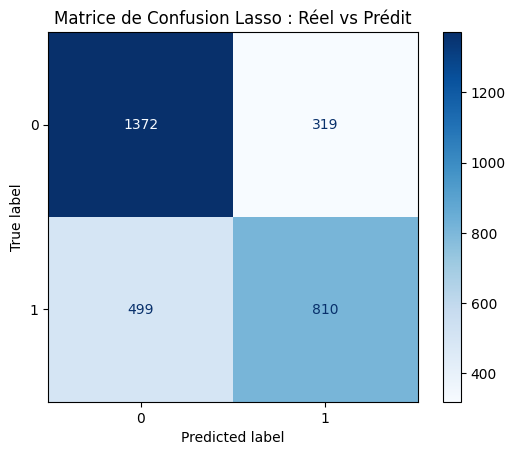

In [19]:
# Générer la matrice
cm = confusion_matrix(Y_test, Y_pred_lasso)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logReg_lasso.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion Lasso : Réel vs Prédit")
plt.show()

Le Lasso a éliminé 0 variables sur 18.
Empty DataFrame
Columns: [Variable, Coefficient]
Index: []


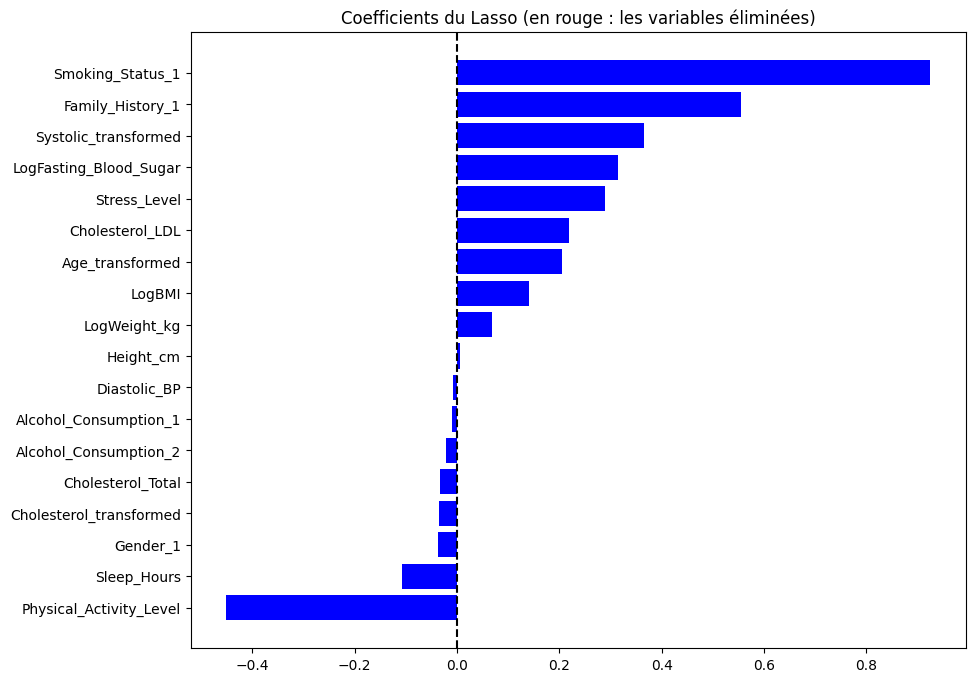

In [20]:
coeffs_df = pd.DataFrame({
    'Variable': health_features.columns, # nom des colonnes, pour l'analyse d'importance des variables
    'Coefficient': logReg_lasso.coef_[0] # .coef_[0] car pour une logistique binaire, c'est une liste de listes
})

variables_eliminees = coeffs_df[coeffs_df['Coefficient'] == 0]

print(f"Le Lasso a éliminé {len(variables_eliminees)} variables sur {len(health_features.columns)}.")
print(variables_eliminees)

coeffs_df = coeffs_df.sort_values(by='Coefficient')

plt.figure(figsize=(10, 8))
plt.barh(coeffs_df['Variable'], coeffs_df['Coefficient'], 
         color=['red' if c == 0 else 'blue' for c in coeffs_df['Coefficient']])
plt.axvline(x=0, color='black', linestyle='--')
plt.title("Coefficients du Lasso (en rouge : les variables éliminées)")
plt.show()

Aucune variable n'a été supprimée, ce qui montre que nos données sont peu redondantes. 

Le modèle a choisi de conserver toutes les variables pour maximiser la précision, cependant, cela ne signifie pas que toutes nos variables ont le même poids.  En traçant le chemin de régularisation afin d'observer la "sensibilité" de chaque coefficients. 

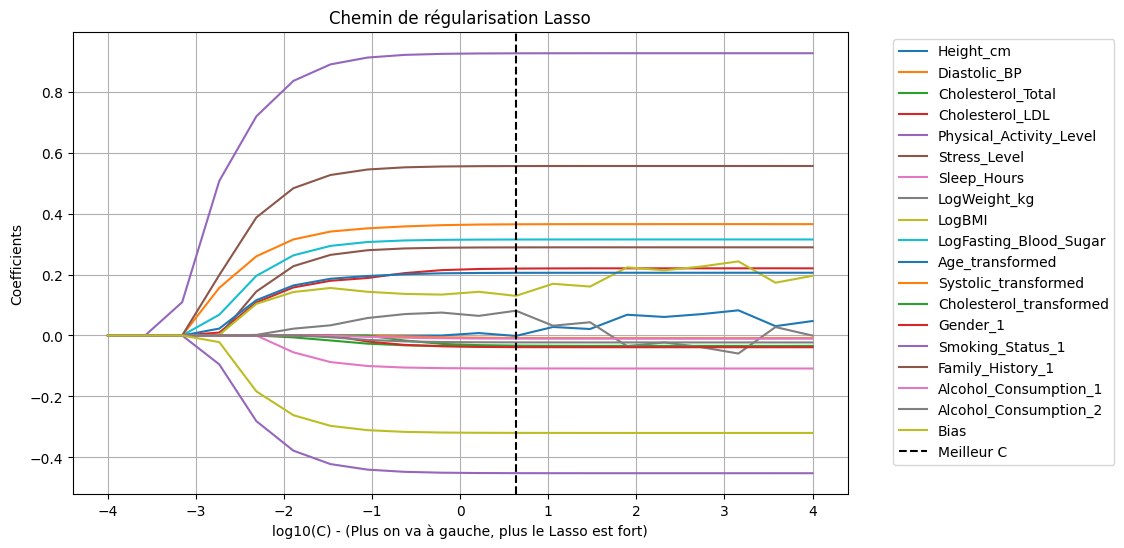

In [21]:
# On récupère les chemins de coefficients (moyenne sur les plis de CV)
paths = logReg_lasso.coefs_paths_[1.0] 
avg_paths = np.mean(paths, axis=0)
cs = logReg_lasso.Cs_

plt.figure(figsize=(10, 6))
for i in range(avg_paths.shape[1]):
    plt.plot(np.log10(cs), avg_paths[:, i], label=health_features.columns[i] if i < len(health_features.columns) else "Bias")

plt.axvline(np.log10(logReg_lasso.C_[0]), linestyle='--', color='k', label='Meilleur C')
plt.xlabel('log10(C) - (Plus on va à gauche, plus le Lasso est fort)')
plt.ylabel('Coefficients')
plt.title('Chemin de régularisation Lasso')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

Ce chemin de régularisation illustre l'entrée progressive des variables dans le modèle à mesure que la pénalité Lasso diminue (augmentation de $C$). On observe que les variables liées au cholestérol et à l'activité physique sont les premières à apparaître et à se stabiliser. On peut donc penser que leur rôle est prépondérant. Au niveau du "Meilleur C" sélectionné (ligne pointillée), l'ensemble des variables a convergé vers une valeur stable.


Lorsqu'on ajoute une pénalisation, on "biaise" les coefficients pour les réduire. Les tests statistiques classiques ne marchent donc plus. Il n'est donc pas forcément pertinent d'utiliser `Statsmodels`.

### 2.3- Modèle linéaire avec pénalisation de Ridge 
Cette méthode vise également à réduire l'overfitting. Cependant, elle n'a pas tendance à rendre des coefficients nuls, au contraire de LASSO. Elle est basée sur la norme L2, et est définie par la formule suivante: 

$$\widehat{\beta} = \text{argmin}_{\widetilde{\beta} \in \mathbb{R}^{p+1}} \left( \| \mathbf{Y} - \widetilde{\mathbf{X}} \widetilde{\beta} \|^2 + \lambda \sum_{j=1}^{p} \beta_j^2 \right) \text{Avec } \lambda \text{ à calibrer}$$

Nous utilisons `LogisticRegressionCV` avec la pénalité 'l2'

In [22]:
logReg_ridge = LogisticRegressionCV(penalty='l2', solver='liblinear', max_iter=10000, cv=5, Cs=20)
logReg_ridge.fit(Xs_train, Y_train)
print(f"Meilleur paramètre C trouvé : {logReg_ridge.C_[0]}")

c:\Users\souve\Bureau\projet-MLBBL\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\souve\Bureau\projet-MLBBL\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\souve\Bureau\projet-MLBBL\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_leg

Meilleur paramètre C trouvé : 0.615848211066026


In [23]:

Y_pred_ridge = logReg_ridge.predict(Xs_test)

# Affichage du score (Précision globale)
print(f"Précision du modèle : {accuracy_score(Y_test, Y_pred_ridge):.3%}")

# Détail des performances (Précision, Rappel par classe)
print(classification_report(Y_test, Y_pred_ridge))

Précision du modèle : 72.733%
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      1691
           1       0.72      0.62      0.66      1309

    accuracy                           0.73      3000
   macro avg       0.73      0.72      0.72      3000
weighted avg       0.73      0.73      0.72      3000



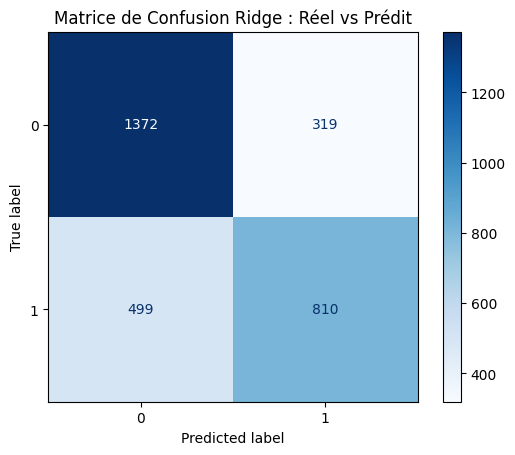

In [24]:
# Générer la matrice
cm = confusion_matrix(Y_test, Y_pred_ridge)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logReg_lasso.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion Ridge : Réel vs Prédit")
plt.show()

Le Ridge a éliminé 0 variables sur 18.
Empty DataFrame
Columns: [Variable, Coefficient]
Index: []


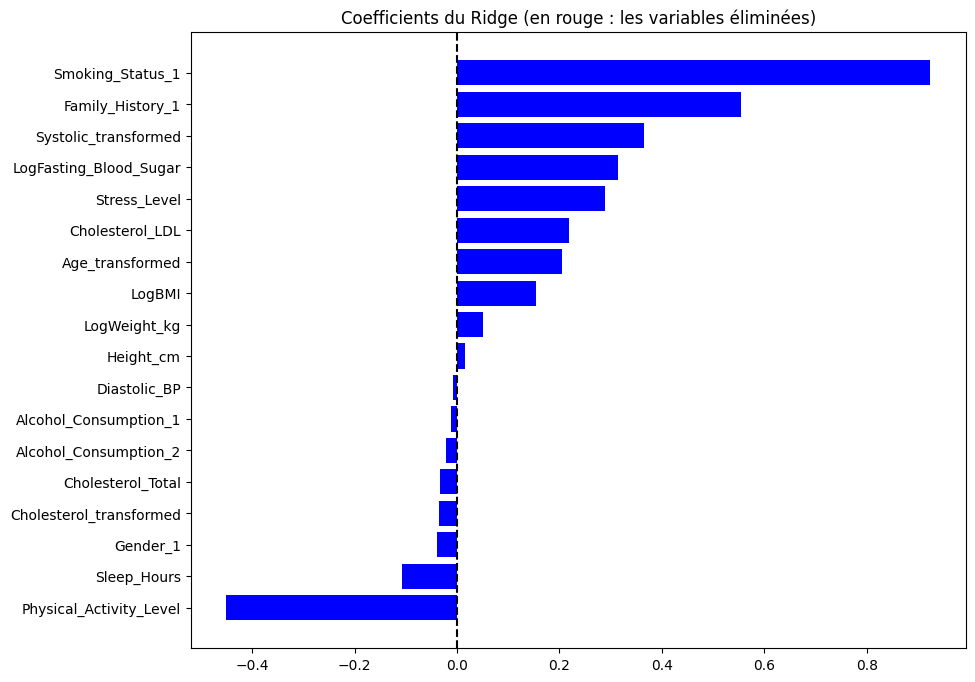

In [25]:
coeffs_df_ridge = pd.DataFrame({
    'Variable': health_features.columns, # nom des colonnes, pour l'analyse d'importance des variables
    'Coefficient': logReg_ridge.coef_[0] # .coef_[0] car pour une logistique binaire, c'est une liste de listes
})

variables_eliminees = coeffs_df_ridge[coeffs_df_ridge['Coefficient'] == 0]

print(f"Le Ridge a éliminé {len(variables_eliminees)} variables sur {len(health_features.columns)}.")
print(variables_eliminees)

coeffs_df_ridge = coeffs_df_ridge.sort_values(by='Coefficient')

plt.figure(figsize=(10, 8))
plt.barh(coeffs_df_ridge['Variable'], coeffs_df_ridge['Coefficient'], 
         color=['red' if c == 0 else 'blue' for c in coeffs_df_ridge['Coefficient']])
plt.axvline(x=0, color='black', linestyle='--')
plt.title("Coefficients du Ridge (en rouge : les variables éliminées)")
plt.show()

Cette méthode donne des resultats similaires à la méthode LASSO, cependant, elle ne supprime aucune variable (ce qui était attendu). 

### 2.4 - Sélection de variable BIC

Nous souhaitons maintenant appliquer une méthode de sélection de variable. Le but est de trouver un modèle qui permet de minimiser le critère BIC : 
$$BIC=-2ln(L)+kln(N)$$
Avec, 
* $L$ la vraisemblance du modèle
* $N$ le nombre d'observations 
* $k$ le nombre de paramètres

Celui ci permet de trouver un compromis entre le nombre de paramètres et la qualité de l'estimation. On cherche à le minimiser en utilisant une méthode de *forward selection* (on ajoute les variables). 

Au contraire de R, il n'existe pas de fonction intégrée, on en écrit donc une. (On aurait également pu forcer un C très petit dans la régréssion LASSO pour supprimer plus de variables)

In [26]:
def forward_selection_bic(X, y): # avec X le dataFramme pandas qu'on a crée 
    best_features = []
    remaining_features = list(X.columns)
    print(remaining_features)
    current_bic = float('inf')
    
    while remaining_features: # tant qu'il reste des variables à tester
        candidates_scores = [] # liste pour stocker les scores BIC de chaque variable candidate
        for candidate in remaining_features: # on boucle sur les variables restantes pour tester leur ajout au modèle
            features_to_test = best_features + [candidate] # on teste le modèle avec les variables déjà retenues + la variable candidate
            X_const = sm.add_constant(X[features_to_test], has_constant='add') # on ajoute aussi l'intercept pour que le modèle puisse apprendre une constante ( pas automatique dans la libraire)
            
            try:
                model = sm.Logit(y.reset_index(drop=True), X_const).fit(disp=0) # on fait le modèle avec la variable candidate 
                candidates_scores.append((model.bic, candidate)) # on met le score BIC et la variable candidate dans la liste
            except:
                continue # si erreur, on ne fait
                
        if not candidates_scores: 
            break
            
        candidates_scores.sort() # Tri pour avoir le score BIC le plus petit au début
        best_new_bic, best_candidate = candidates_scores[0] # on prend la variable candidate qui a le meilleur score BIC (le plus petit)
        
        if best_new_bic < current_bic: # Si le meilleur BIC trouvé est plus petit que l'actuel, on valide la variable
            remaining_features.remove(best_candidate) # on retire la variable candidate des variables restantes à tester
            best_features.append(best_candidate) # on ajoute la variable candidate à la liste des variables retenues
            current_bic = best_new_bic # on met à jour le BIC actuel avec le meilleur BIC trouvé
            print(f"Ajouté : {best_candidate} -> Nouveau BIC : {current_bic:.2f}")
        else:
            # L'ajout d'une variable supplémentaire augmente le BIC (le modèle devient trop complexe), on s'arrête
            print("L'ajout de nouvelles variables n'améliore plus le BIC. Fin.")
            break
            
    print(f"\nVariables finales retenues par le BIC : {best_features}")
    return best_features


In [27]:
X_train_df = pd.DataFrame(Xs_train, columns=health_features.columns)
variables_optimales = forward_selection_bic(X_train_df, Y_train)
print("nombres de variables retenues : ", len(variables_optimales), " sur ", len(health_features.columns))

['Height_cm', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Physical_Activity_Level', 'Stress_Level', 'Sleep_Hours', 'LogWeight_kg', 'LogBMI', 'LogFasting_Blood_Sugar', 'Age_transformed', 'Systolic_transformed', 'Cholesterol_transformed', 'Gender_1', 'Smoking_Status_1', 'Family_History_1', 'Alcohol_Consumption_1', 'Alcohol_Consumption_2']
Ajouté : Smoking_Status_1 -> Nouveau BIC : 14908.26
Ajouté : Family_History_1 -> Nouveau BIC : 14319.49
Ajouté : Systolic_transformed -> Nouveau BIC : 13769.03
Ajouté : Physical_Activity_Level -> Nouveau BIC : 13395.87
Ajouté : LogFasting_Blood_Sugar -> Nouveau BIC : 13121.39
Ajouté : Stress_Level -> Nouveau BIC : 12957.71
Ajouté : Cholesterol_LDL -> Nouveau BIC : 12814.90
Ajouté : LogBMI -> Nouveau BIC : 12762.90
Ajouté : Age_transformed -> Nouveau BIC : 12711.72
Ajouté : Sleep_Hours -> Nouveau BIC : 12696.37
L'ajout de nouvelles variables n'améliore plus le BIC. Fin.

Variables finales retenues par le BIC : ['Smoking_Status_1', 'Family_Hi

In [28]:
Xs_BIC=X_train_df[variables_optimales] # on garde uniquement les variables retenues par le BIC pour l'entraînement du modèle final
logReg_BIC = LogisticRegression(penalty=None, max_iter=10000)
logReg_BIC.fit(Xs_BIC, Y_train) 

c:\Users\souve\Bureau\projet-MLBBL\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [29]:
X_test_df = pd.DataFrame(Xs_test, columns=health_features.columns)
Xs_test_BIC = X_test_df[variables_optimales]
y_pred_BIC = logReg_BIC.predict(Xs_test_BIC)
print(classification_report(Y_test, y_pred_BIC))
print(f"Accuracy globale : {accuracy_score(Y_test, y_pred_BIC):.3%}")

              precision    recall  f1-score   support

           0       0.74      0.82      0.77      1691
           1       0.72      0.62      0.67      1309

    accuracy                           0.73      3000
   macro avg       0.73      0.72      0.72      3000
weighted avg       0.73      0.73      0.73      3000

Accuracy globale : 73.067%


Cette méthode donnes des résultats moins satisfaisant que les précédentes. Cependant, elle a supprimé plus de la moitié des variables, ce qui est un avantage considérable. 

### 2.4- Conclusion 


In [30]:

def generer_tableau_final(models_dict, X_test, Y_test, cols_bic=None, feature_names=None):
    stats = []
    X_test_df = pd.DataFrame(X_test, columns=feature_names) if feature_names is not None else X_test

    for name, model in models_dict.items():
        # Sélection des colonnes pour le BIC
        X_input = X_test_df[cols_bic] if (name == 'BIC' and cols_bic is not None) else X_test
        
        y_pred = model.predict(X_input)
        report = classification_report(Y_test, y_pred, output_dict=True)
        
        # On met 0.0 au lieu de "X" pour éviter les erreurs de type dans le tableau
        c_val = model.C_[0] if hasattr(model, 'C_') else 0.0
            
        # Variables éliminées
        if name == 'BIC':
            var_eliminees = X_test_df.shape[1] - len(cols_bic)
        else:
            var_eliminees = sum(1 for c in model.coef_.flatten() if abs(c) < 1e-10)

        stats.append({
            'Modèle': name,
            'C': float(c_val),
            'Accuracy': report['accuracy'],
            'Prec_0': report['0']['precision'],
            'Prec_1': report['1']['precision'],
            'Rec_0': report['0']['recall'],
            'Rec_1': report['1']['recall'],
            'Eliminées': int(var_eliminees)
        })

    # On crée le DataFrame
    df = pd.DataFrame(stats).set_index('Modèle').T
    
    # On applique les couleurs uniquement sur les lignes numériques 
    # (On exclut la ligne 'C' et 'Eliminées' pour le dégradé si besoin)
    return df.style.format(precision=3).background_gradient(cmap='Blues', axis=1)

modeles = {
    'Sans pénalisation': logReg_none, # Ton modèle sklearn avec penalty=None
    'Lasso (L1)': logReg_lasso,
    'Ridge (L2)': logReg_ridge,
    'BIC': logReg_BIC            
}
tableau = generer_tableau_final(modeles, Xs_test, Y_test, variables_optimales, health_features.columns)
tableau

Modèle,Sans pénalisation,Lasso (L1),Ridge (L2),BIC
C,0.000,4.281,0.616,0.000
Accuracy,0.727,0.727,0.727,0.731
Prec_0,0.733,0.733,0.733,0.735
Prec_1,0.717,0.717,0.717,0.723
Rec_0,0.811,0.811,0.811,0.816
Rec_1,0.619,0.619,0.619,0.620
Eliminées,0.000,0.000,0.000,8.000


### Conclusion 
fait par gemini à modifier 

1-Stabilité des performances : "L'application des pénalités L1, L2 et la sélection BIC montrent une convergence vers une accuracy de 0.74, ce qui suggère que le modèle a atteint sa capacité prédictive maximale pour une approche linéaire."

2-Interprétation du BIC : "Le modèle BIC est à privilégier car il offre la même performance (0.74) avec une structure plus simple, limitant ainsi les risques d'overfitting sur de nouvelles données."

3-Analyse des erreurs : Regarde si ce sont les mêmes individus qui sont mal classés par tous les modèles. Si oui, c'est que ces individus sont des "atypiques" que tes variables actuelles ne peuvent pas expliquer1

**FINIR QUAND ON AURA LA REPONSE**

## 3-SVM

Les *linear support vector machine* visent à distinguer nos deux classes (à risque de maladies cardiaques vs non à risque) en trouvant l'hyperplan optimal qui maximise la marge entre les points les plus proches de classes opposées. Ces points sont appelés les *vecteurs de support*. Si nos données ne sont pas linéaires, on utilise l'astuce du noyau afin de les projeter dans une dimension supérieure et de trouver un plan qui les sépare correctement. 

Afin de trouver les meilleurs paramètres, nous faisons un Gridsearch, nous cherchons à optimiser deux paramètres: 
* **C** :  controle le compromis entre la bonne classification des classes et la simplicité de la frontière. Plus C est petit plus il aura tendance à accepter les erreurs pour favoriser la généralisation. 
* **Kernel** : Ce choix dépend de la forme de la frontière : 
    * *Linéaire* : est utilisé si les données sont linéairement séparables 
    * *RBF* : crée des frontières en forme de bulles 
    * *Poly* : crée des frontières de forme polynomiales 

In [ ]:
from sklearn.svm import SVC # code prit du TP Ozonne 
from sklearn.model_selection import GridSearchCV

# On définit la grille pour tester C ET les différents noyaux
param_grid = [
    {
        'C': [0.1, 1,5, 10], 
        'kernel': ['linear', 'rbf', 'poly','sigmoid'], 
        'degree': [2, 3] # Seulement utilisé par le noyau 'poly'
    }
]

# On lance la recherche
grid_svm = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1)
grid_svm.fit(Xs_train, Y_train)

print("Meilleur noyau trouvé :", grid_svm.best_params_['kernel'])
print("Meilleur score :", grid_svm.best_score_)

Meilleur noyau trouvé : rbf
Meilleur score : 0.7343333333333334


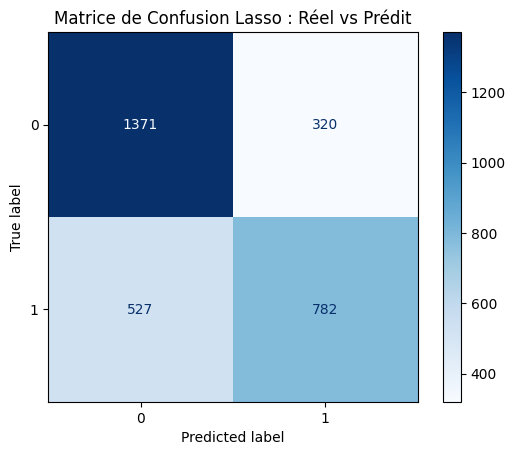

              precision    recall  f1-score   support

           0       0.72      0.81      0.76      1691
           1       0.71      0.60      0.65      1309

    accuracy                           0.72      3000
   macro avg       0.72      0.70      0.71      3000
weighted avg       0.72      0.72      0.71      3000



In [32]:
# prévision de l'échantillon test
Y_pred_svm = grid_svm.predict(Xs_test)
# matrice de confusion
cm = confusion_matrix(Y_test, Y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_svm.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion Lasso : Réel vs Prédit")
plt.show()

print (classification_report(Y_test, Y_pred_svm))

ainsi blablal


## 4- Arbre optimal et forets aléatoires

### 4.1- Arbre Optimal 
La technique de l'arbre optimal permet de classifier les données et de visualiser quels critères ont été utilisés pour prendre cette décision. 

Afin de trouver la meilleure **dans quel sens** profondeur d'arbre, on utilise un gridsearch 

Nous créons un PDF afin d'améliorer la visibilité de l'abre. 

In [40]:
from sklearn.tree import DecisionTreeClassifier
# Optimisation de la profondeur de l'arbre
param=[{"max_depth":list(range(2,10))}]
tree= GridSearchCV(DecisionTreeClassifier(),param,cv=10,n_jobs=-1)
treeOpt=tree.fit(Xs_train, Y_train)
# paramètre optimal
print("Meilleur score = %f, Meilleur paramètre = %s" % (treeOpt.best_score_,treeOpt.best_params_))

Meilleur score = 0.714833, Meilleur paramètre = {'max_depth': 6}


In [42]:
 # Estimation de l'erreur de prévision
treeOpt.score(Xs_test,Y_test)

0.6966666666666667

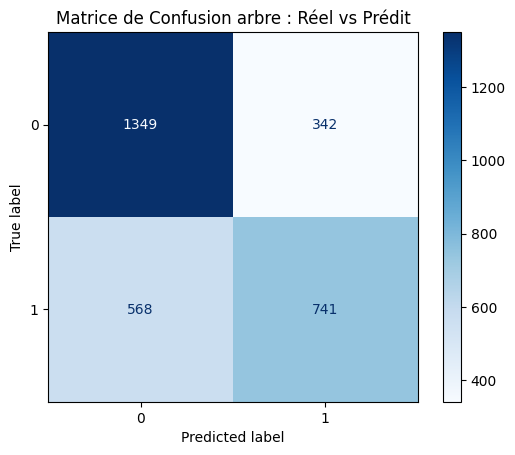

              precision    recall  f1-score   support

           0       0.70      0.80      0.75      1691
           1       0.68      0.57      0.62      1309

    accuracy                           0.70      3000
   macro avg       0.69      0.68      0.68      3000
weighted avg       0.70      0.70      0.69      3000



In [43]:
# prévision de l'échantillon test
y_pred_tree = treeOpt.predict(Xs_test)
cm = confusion_matrix(Y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=treeOpt.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion arbre : Réel vs Prédit")
plt.show()

print (classification_report(Y_test, y_pred_tree))

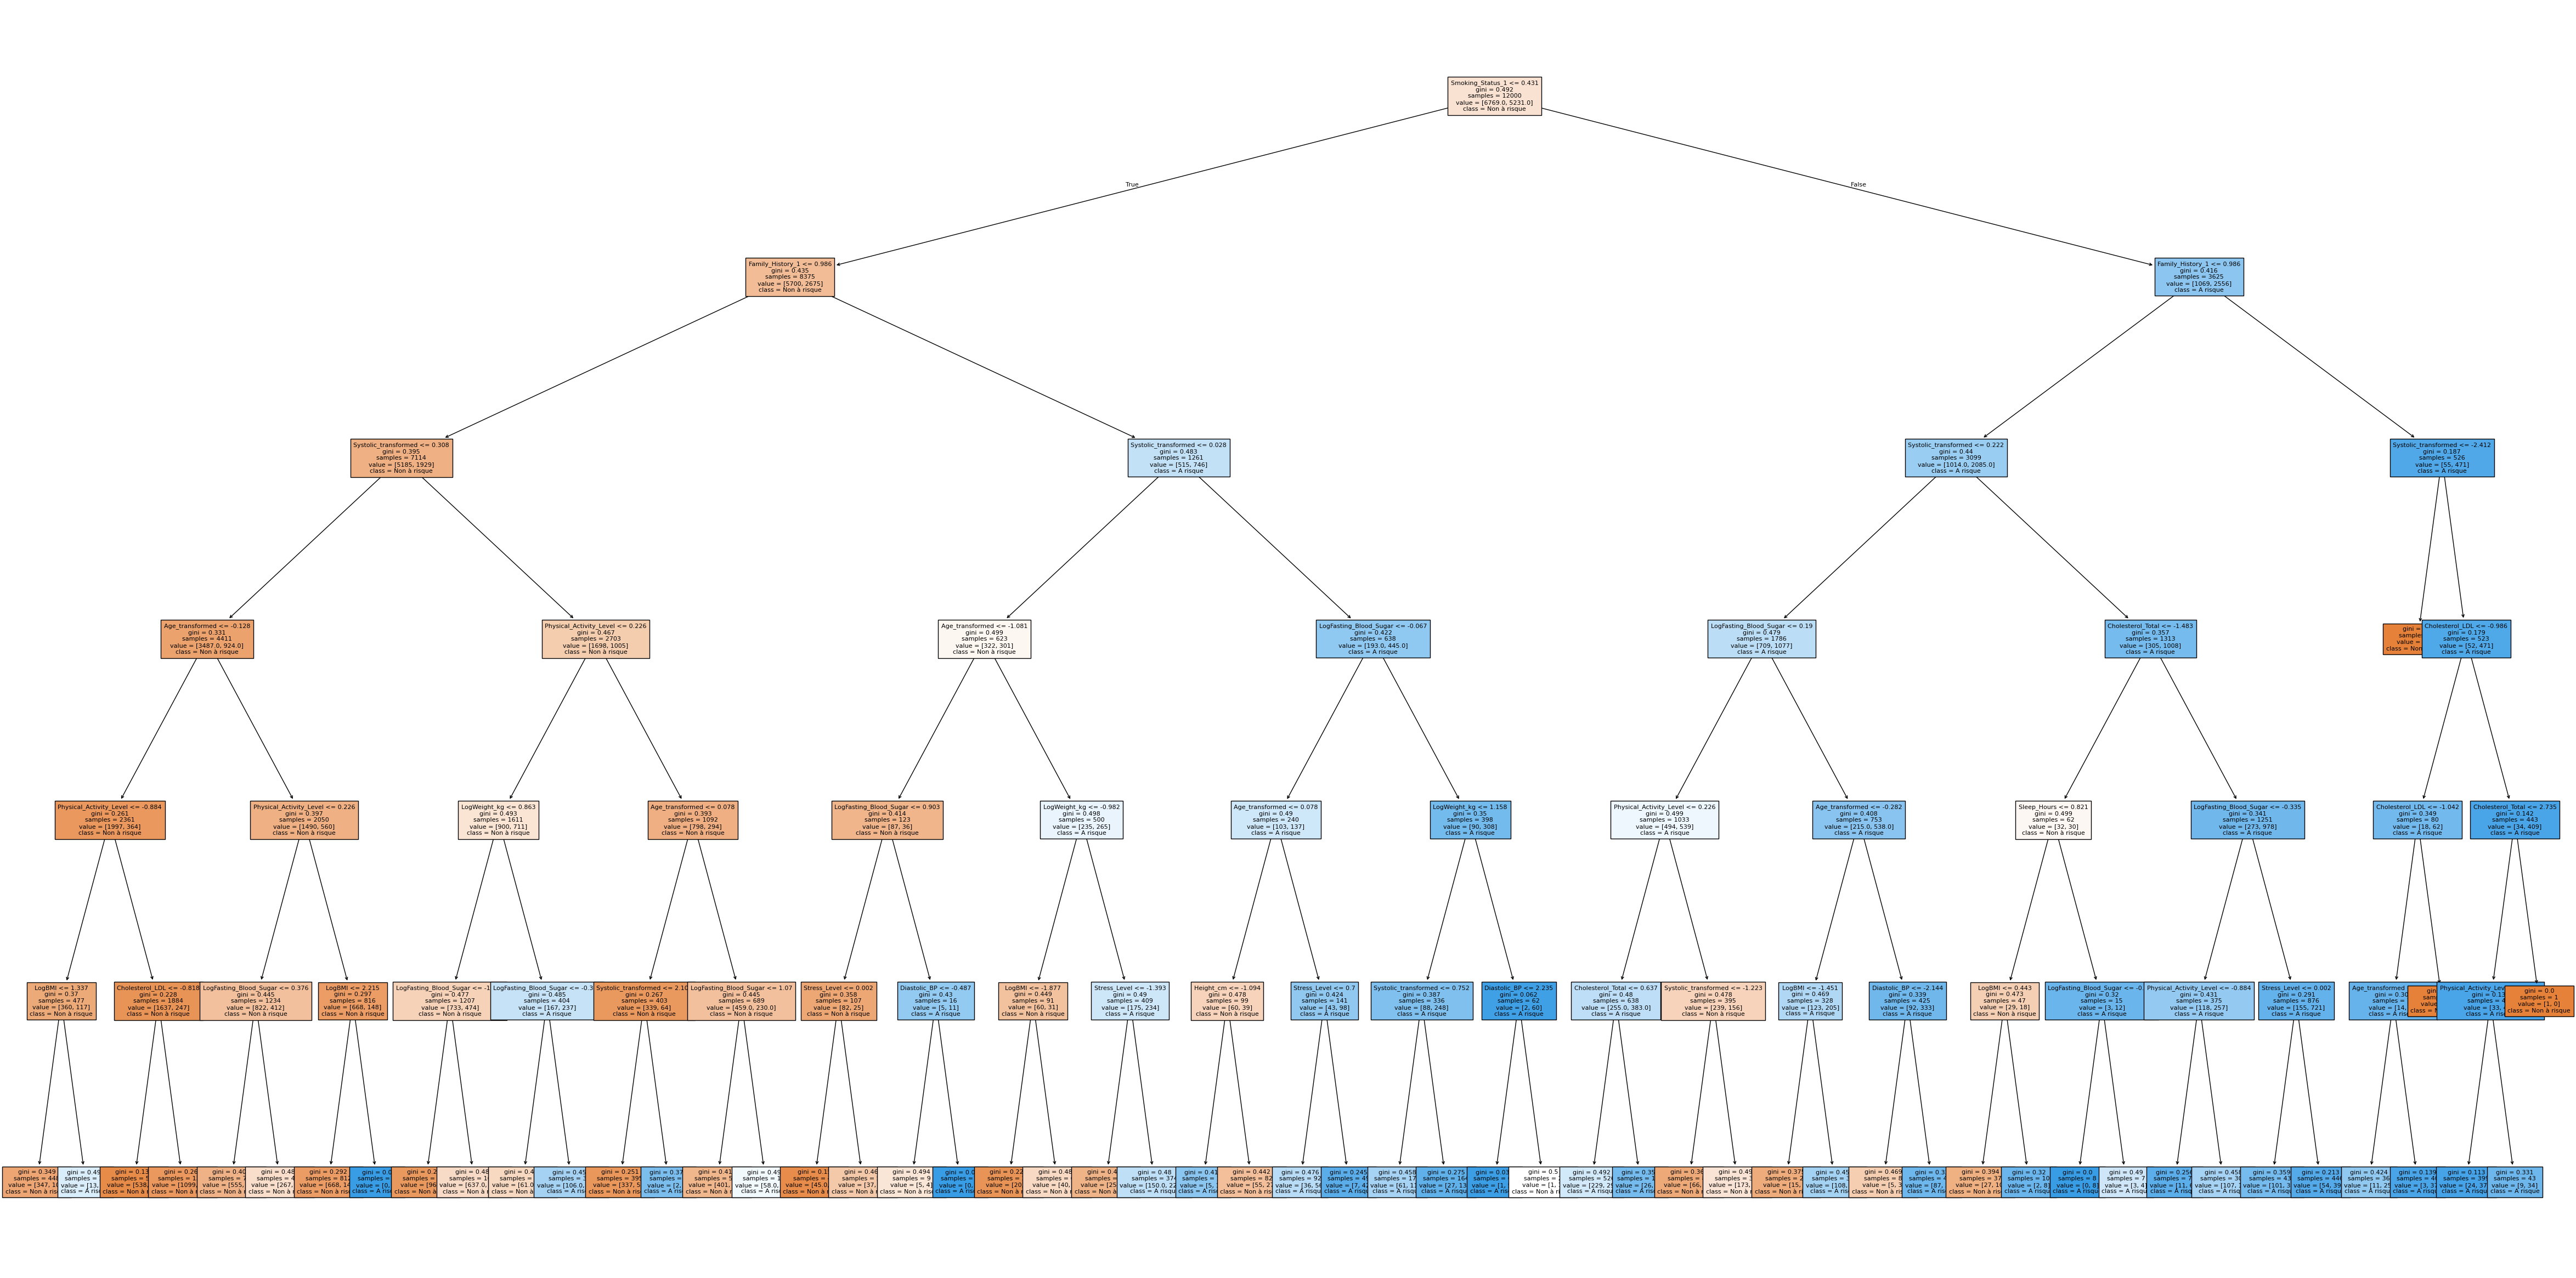

In [49]:
from sklearn.tree import plot_tree
plt.figure(figsize=(60, 30)) # On voit TRÈS grand
plot_tree(treeOpt.best_estimator_, feature_names=health_features.columns.tolist(), class_names=['Non à risque', 'A risque'], filled=True, fontsize=8)

# Sauvegarde en PDF (le texte ne sera jamais flou et pourra être agrandi)
plt.savefig("arbre_python.pdf", format='pdf', bbox_inches='tight')
plt.show()

Les feuilles finales indiquent la classe prédite, et leur couleur nous indiquent la probabilité d'appartenir à la classe. PLus la feuille est foncée, plus le modèle est "sûr" de son choix. Nous pouvons remarquer que les premieres feuilles correspondent aux premieres variables ajoutées par la séléction de variables forward, ce qui confirme qu'elles ont un poids prédominant dans la création des modèles.Le fait de fumer est donc l'indicateur principal des maladies cardiaques. 

### 4-2. Forets aléatoires 

## 5- Boosting 

Le boosting consiste à utiliser plusieurs apprenants faibles à la suite, chacun corrigeant les erreurs du précédent. *L'AdaBoost* identifie les points mals classés et augmente leurs poids pour l'apprenant suivant. Le *Boosting de Gradient* cherche quant à lui à prédire les résidus de l'apprenant précédent, afin de s'approcher pas à pas de la solution réelle. 

On compare ces deux méthodes. 

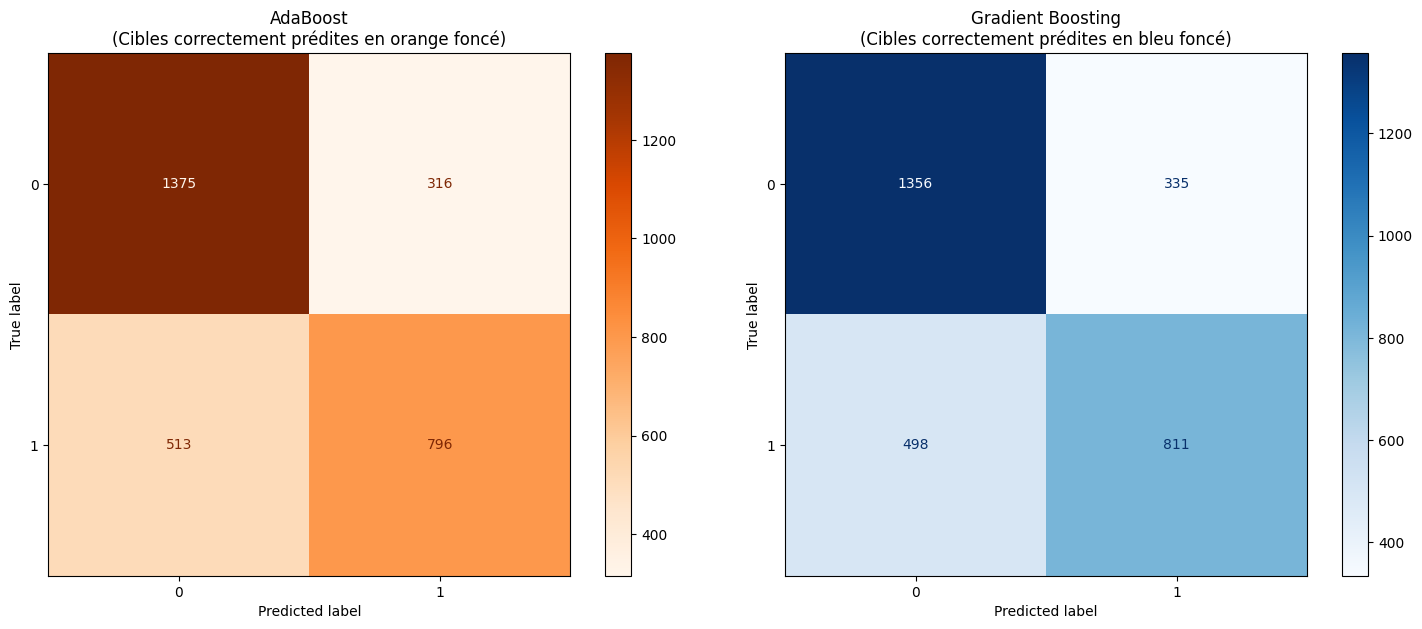


--- RAPPORT ADABOOST ---
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      1691
           1       0.72      0.61      0.66      1309

    accuracy                           0.72      3000
   macro avg       0.72      0.71      0.71      3000
weighted avg       0.72      0.72      0.72      3000


--- RAPPORT GRADIENT BOOSTING ---
              precision    recall  f1-score   support

           0       0.73      0.80      0.77      1691
           1       0.71      0.62      0.66      1309

    accuracy                           0.72      3000
   macro avg       0.72      0.71      0.71      3000
weighted avg       0.72      0.72      0.72      3000



In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

#adaboost
param_ada = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1]} # n_estimators = nombres de modèles faibles (arbres) à entraîner, learning_rate = poids que le modèle faible va avoir dans la combinaison finale
grid_ada.fit(Xs_train, Y_train)
best_ada = grid_ada.best_estimator_

#boosting de gradient 
param_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1], # taille du pas vers la décision finale, plus il est petit, plus le modèle apprend lentement et peut potentiellement mieux généraliser, mais cela nécessite plus d'arbres (n_estimators) pour converger
    'max_depth': [3, 4, 5] # Profondeur des arbres dans le boosting
}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_gb, cv=5, n_jobs=-1)
grid_gb.fit(Xs_train, Y_train)
best_gb = grid_gb.best_estimator_

# comparaison visuelle
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Matrice AdaBoost
disp_ada = ConfusionMatrixDisplay.from_estimator(best_ada, Xs_test, Y_test, cmap='Oranges', ax=ax1)
ax1.set_title(f"AdaBoost")

# Matrice Gradient Boosting
disp_gb = ConfusionMatrixDisplay.from_estimator(best_gb, Xs_test, Y_test, cmap='Blues', ax=ax2)
ax2.set_title(f"Gradient Boosting")

plt.tight_layout()
plt.show()

#rapports détaillés
print("\n--- RAPPORT ADABOOST ---")
print(classification_report(Y_test, best_ada.predict(Xs_test)))

print("\n--- RAPPORT GRADIENT BOOSTING ---")
print(classification_report(Y_test, best_gb.predict(Xs_test)))

Nous n'avons ici pas une meilleure précision du boosting. J'ai l'impression que le boosting a plus tendance à prédire des 1 **TRACER COURBES ROC**

## 6-Réseaux de neurones 

Le but de cette méthode est de faire passer nos données à travers plusieurs couches leur apportant des modifications, puis d'ajuster les poids de chaque fonction afin de classifier correctement nos données. 

In [51]:
from sklearn.neural_network import MLPClassifier
param_grid=[{"hidden_layer_sizes":list([(5,),(6,),(7,),(8,)])}]
nnet= GridSearchCV(MLPClassifier(max_iter=500),param_grid,cv=10,n_jobs=-1)
nnetOpt=nnet.fit(Xs_train, Y_train)
print("Meilleur score = %f, Meilleur paramètre = %s" % (nnetOpt.best_score_,nnetOpt.best_params_))

Meilleur score = 0.740500, Meilleur paramètre = {'hidden_layer_sizes': (5,)}


In [ ]:
# prévision de l'échantillon test
y_pred_neur = nnetOpt.predict(Xs_test)


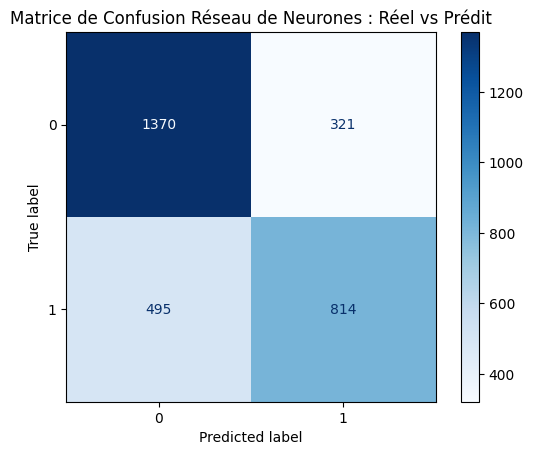

              precision    recall  f1-score   support

           0       0.73      0.81      0.77      1691
           1       0.72      0.62      0.67      1309

    accuracy                           0.73      3000
   macro avg       0.73      0.72      0.72      3000
weighted avg       0.73      0.73      0.72      3000



In [53]:

# matrice de confusion
cm = confusion_matrix(Y_test, y_pred_neur)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nnetOpt.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion Réseau de Neurones : Réel vs Prédit")
plt.show()

print (classification_report(Y_test, y_pred_neur))